#### 모델링 : 함수 찾기
- 집의 평수를 알면 가격을 알 수있을까?
- Y = aX +b
- 데이터를 잘 설명하는 직선 하나를 찾는 것이 모델링
#### 손으로 숫자를 그린 이미지를 보고 숫자 7인지 맞출 수 있을까?
- 아주 복잡한 결정경계를 그린다. 경계를 그려주는 함수를 찾아내는 과정
##### ANN 인공신경망
- 단일층 : 신셩망이 하나 퍼셉트론 1x1 -> 뉴런
- 다층

외부의 자극이 들어와도 어떤 임계치 이상의 자극이 들어와야 감각이 인식이된다.
실제 신경반응과 유사

딥러닝에서
인공신경망이 구조라면, 활성화함수는 기능에 가깝다
구조만 있으면 선형 계산만 되고, 활성화 함수를 통해 비선형 패턴을 학습할 수 있음.

#### 활성화 함수...
- 계단 함수
- 시그모이드 Logisticfunction
    ```
    : 연속적인 값을 출력 - 미분이 가능 - 오차 역전파
    활성화 함수가 없다... f(z) = z
    y = (W100 x .... W1)X --> 거대한 1층짜리 선형모델
    초기 활성화 함수 스위치
    계단함수 if x > 0 1
            x <=   0
    주의 : 기울기 소실현상
    ```

#### 다층 신경망 MLP : 퍼셉트론을 여러개 쌓아서 올린구조
    - input layer : 데이터가 들어오는 곳(뉴런수 데이터의 특성 28X28 = 784)
    - hidden layer : 입력과 출력 사이에 있는 레이어
        # 이 숨겨진 레이어에서 양이 늘어났다 줄어들수도있다 줄었다가 늘어나서 간추릴 수도 있다.

In [1]:
%pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   - -------------------------------------- 11.8/332.0 MB 63.7 MB/s eta 0:00:06
   -- ------------------------------------- 23.9/332.0 MB 60.5 MB/s eta 0:00:06
   ---- ----------------------------------- 34.1/332.0 MB 54.7 MB/s eta 0:00:06
   ---- ----------------------------------- 41.2/332.0 MB 49.0 MB/s eta 0:00:06
   ------ --------------------------------- 50.6/332.0 MB 48.0 MB/s eta 0:00:06
   ------ --------------------------------- 56.6/332.0 MB 44.9 MB/s eta 0:00:07
   ------- -------------------------------- 60.8/332.0 MB 42.3 MB/s eta 0:00:07
   ------- -------------------------------- 65.8/332.0 MB 38.8 MB/s eta 0:00:07
   -------- ------------------------------- 69.2/332.0 MB 36.6 MB/s eta 0:00:08
   -------- ------------------------------- 73.4/332.0 MB 34.5 MB/s eta 0:00:08
   --------- ------------------------------ 77.1/332.0 MB 33.2 MB/s eta 0:00:08
   --------- ------------------------------ 81.5/

In [5]:
# 파이토치로 딥러닝 샘플 만들어보기
# 파이토치 시작...!

# 필요 라이브러리
from sklearn.datasets import fetch_openml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# X, y = fetch_openml('mnist_784',version=1,return_X_y=True,parser='Auto')

In [8]:
# MNIST  데이터셋 로드
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [9]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

4
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38
  190  25   0   0   0   0   0   0   0   0]
 [  0   0   0  13  25  10   0   0   0   0   0   0   0   0   0   0   0 112
  252 125   4   0   0   0   0   0   0   0]
 [  0   0   0 132 252 113   0   0   0   0   0   0   0   0   0   0   0  61
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 240  79   0   0   0   0   0   0   0   0   0   0  84
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 252 238  52   0   0   0   0   0   0   0 

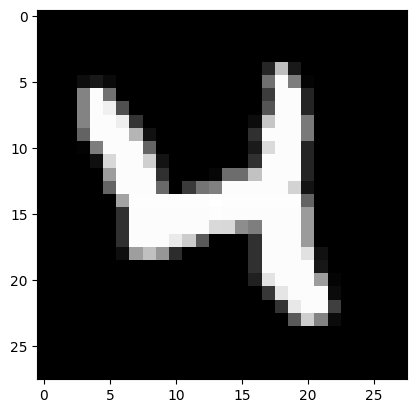

In [11]:
print(y_train[20])
plt.imshow(x_train[20],cmap='gray')
print(x_train[20])

In [14]:
# 데이터를 스케일링 : 표준화 :임의로 숫자를 정하여 나눠주기 :
    # 255로 나누기 -> 그 이유 : 0 ~ 255 이루어진 데이터 이기 때문에 255로 나누면 0~1사이의 값으로 스케일이 조정된다.
# 동일한 타입으로 연산하면 연산속도가 조금 더 빨라진다. 실수로 통일 ^ 실수로 통일한 이유? ^
x_train = x_train.astype(float) / 255.0
x_test = x_test.astype(float) / 255.0

In [ ]:
# 데이터를 1차원형태로 넣어야 한다. -> keras의 기능 사용, keras.layers.Flatten() : only 데이터를 펴주는 기능

model = tf.keras.Sequential([
    # 1층 입력층 28 x 28  2D -> 784 ID
    tf.keras.layers.Flatten(input_shape=(28,28)),
    # 2층 은닉층
    tf.keras.layers.Dense(128,activation='relu'),  # ^
    # 출력층
    tf.keras.layers.Dense(10,activation='sigmoid') # 마지막 레이어에는 시그모이드를 사용한다.
])